In [7]:
import pandas as pd
import plotly.express as px


# Dataset: Gapminder — GDP, Life Expectancy, Population by Country
# Source: Gapminder Foundation (gapminder.org)

df = px.data.gapminder()
print(f"Loaded: {len(df)} rows")
print(df.head())
# explore

print(df.info())
print("Years:", sorted(df['year'].unique()))
print("Continents:", df['continent'].unique())
print(df.describe().round(1))

Loaded: 1704 rows
       country continent  year  lifeExp       pop   gdpPercap iso_alpha  \
0  Afghanistan      Asia  1952   28.801   8425333  779.445314       AFG   
1  Afghanistan      Asia  1957   30.332   9240934  820.853030       AFG   
2  Afghanistan      Asia  1962   31.997  10267083  853.100710       AFG   
3  Afghanistan      Asia  1967   34.020  11537966  836.197138       AFG   
4  Afghanistan      Asia  1972   36.088  13079460  739.981106       AFG   

   iso_num  
0        4  
1        4  
2        4  
3        4  
4        4  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
 6   iso_alpha  1704 non-nu

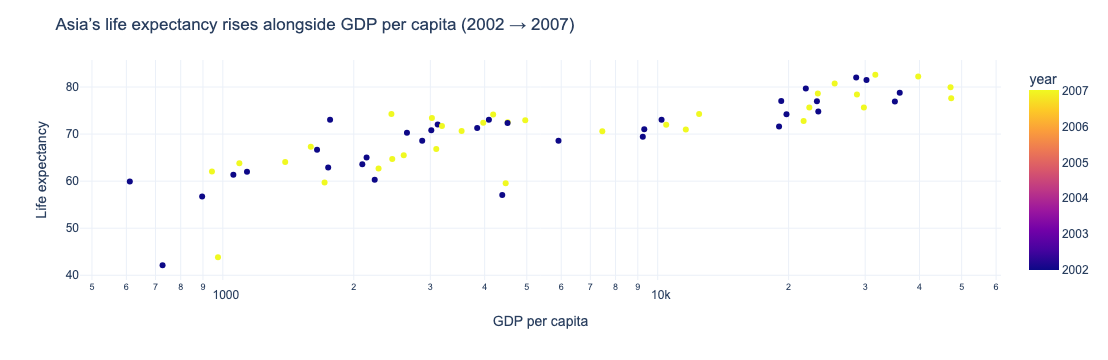

In [10]:
asia = df[df['continent'] == 'Asia']
data = asia[asia['year'].isin([2002, 2007])]

fig = px.scatter(
    data,
    x="gdpPercap",
    y="lifeExp",
    color="year",
    color_discrete_sequence=["#FF69B4", "#2ECC71"],
    hover_name="country",
    size_max=10
)

fig.update_layout(
    title="Asia’s life expectancy rises alongside GDP per capita (2002 → 2007)",
    xaxis_title="GDP per capita",
    yaxis_title="Life expectancy",
    template="plotly_white",
    font=dict(family="Arial")
)

fig.update_xaxes(type="log")

fig.show()

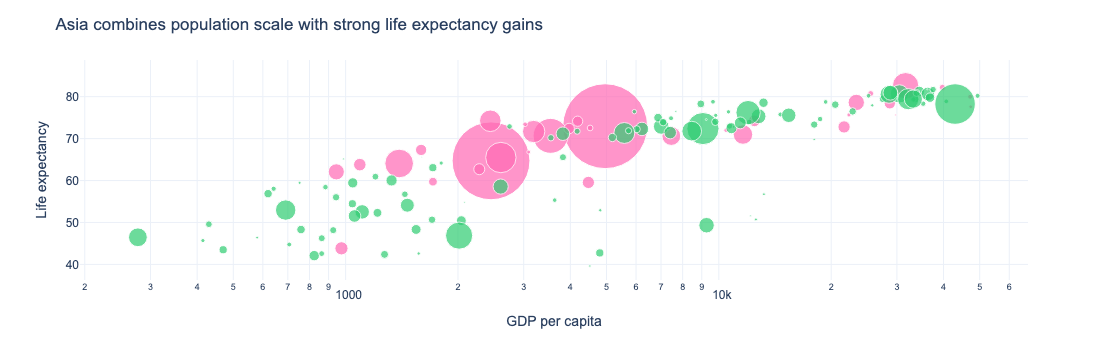

In [9]:
data = df[df['year'] == 2007].copy()

data["color"] = "Other"
data.loc[data["continent"] == "Asia", "color"] = "Asia"

fig = px.scatter(
    data,
    x="gdpPercap",
    y="lifeExp",
    size="pop",
    color="color",
    hover_name="country",
    size_max=60,
    color_discrete_map={
        "Asia": "#FF69B4",
        "Other": "#2ECC71"
    }
)

fig.update_layout(
    title="Asia combines population scale with strong life expectancy gains",
    xaxis_title="GDP per capita",
    yaxis_title="Life expectancy",
    template="plotly_white",
    font=dict(family="Arial"),
    showlegend=False
)

fig.update_xaxes(type="log")

fig.add_annotation(
    x=20000,
    y=75,
    text="Asia spans wide income levels but clusters in improving life expectancy",
    showarrow=False,
    font=dict(size=12)
)

fig.show()
